# Marketing × Sales Analysis

Цель анализа — сопоставить маркетинговые события с продажами и оценить,
как меняются продажи после маркетинговых активностей.

Важно:
- историческая атрибуция пользователей недоступна;
- рост продаж после события не доказывает причинный эффект;
- результаты ниже интерпретируются как наблюдаемая ассоциация маркетинга и продаж;
- продажи доступны только с 04.08.2026, поэтому анализ проводится только на пересекающемся временном диапазоне.

In [159]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [160]:
SALES_PATH = Path("../data/raw/base.xlsx")
MARKETING_PATH = Path("../data/raw/marketing_history.xlsx")

In [161]:
sales = pd.read_excel(
    SALES_PATH,
    sheet_name="Данные"
)

sales = sales.rename(columns={
    "Номер студента": "student_id",
    "Сумма": "amount",
    "Курс": "course",
    "Время": "timestamp",
})

sales["timestamp"] = pd.to_datetime(
    sales["timestamp"],
    errors="coerce"
)

sales.head()

,student_id,amount,course,timestamp
0,437,"8,950.00",ML про,2026-08-04 09:08:31
1,437,"7,890.00",Аналитика старт,2026-08-04 09:35:00
2,443,"8,475.00",Линейная алгебра,2026-08-04 10:14:38
3,443,"8,475.00",Мат анализ,2026-08-04 10:14:38
4,430,"8,950.00",К ВУЗу,2026-08-04 13:38:06


In [162]:
marketing = pd.read_excel(
    MARKETING_PATH,
    header=2
)

marketing["event_time"] = pd.to_datetime(
    marketing["event_time"],
    errors="coerce"
)

marketing.head()

,event_id,event_time,source_channel,activity_type,course,campaign,placement,creative_text,external_or_internal,post_url,views,reactions,cost_rub,data_source,confidence,collected_by,notes,channel_relationship,paid_status,raw_origin,raw_category,raw_period,raw_media,raw_forwarded_from,raw_links,raw_promo_candidate,raw_offer_flag,raw_discount_flag,raw_launch_flag,raw_lead_magnet_flag,raw_ad_marking,raw_erid,raw_scraped_at,raw_html_ref,Unnamed: 34,product_scope,product_line,inferred_course,content_direction,candidate_courses
0,INT-1764,2026-07-01 18:10:49,@postypashki_old,Контент с предложением курсов,ML старт | Data Science,NaN,postypashki_old/1764,Самые интересные события в ближайшее время.\nВ...,internal,https://t.me/postypashki_old/1764,21200,42.00,NaN,Telegram,raw,Codex,Самые интересные события в ближайшее время. Вс...,internal,unknown,telegram_internal,Контент с предложением курсов,Предыстория,NaN,NaN,NaN,NaN,1.00,0.00,0.00,0.00,NaN,False,2026-07-01T15:10:49+00:00,NaN,NaN,multiple_courses,START,NaN,career,ML старт | Data science
1,INT-1765,2026-07-02 18:31:22,@postypashki_old,Прочий контент,NaN,NaN,postypashki_old/1765,"В новом ролике обсудим, что с вашей психикой с...",internal,https://t.me/postypashki_old/1765,17500,50.00,NaN,Telegram,raw,Codex,"В новом ролике обсудим, что с вашей психикой с...",internal,unknown,telegram_internal,Прочий контент,Предыстория,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,NaN,False,2026-07-02T15:31:22+00:00,NaN,NaN,unknown,NaN,NaN,career,NaN
2,INT-1767,2026-07-04 12:03:55,@postypashki_old,Промо со скидкой,NaN,NaN,postypashki_old/1767,❗️ Завтра заканчивается донабор на стажировку ...,internal,https://t.me/postypashki_old/1767,18600,25.00,NaN,Telegram,raw,Codex,❗️ Завтра заканчивается донабор на стажировку ...,internal,unknown,telegram_internal,Промо со скидкой,Предыстория,NaN,NaN,NaN,NaN,1.00,1.00,0.00,0.00,NaN,False,2026-07-04T09:03:55+00:00,NaN,NaN,product_line,START,NaN,career,Аналитика старт | Алгоритмы старт | Backend ст...
3,INT-1768,2026-07-04 15:35:53,@postypashki_old,Контент с предложением курсов,ML старт,NaN,postypashki_old/1768,Академия Авито и Буткем Авито \n\nСегодня прош...,internal,https://t.me/postypashki_old/1768,20400,26.00,NaN,Telegram,raw,Codex,Академия Авито и Буткем Авито Сегодня прошел п...,internal,unknown,telegram_internal,Контент с предложением курсов,Предыстория,NaN,NaN,NaN,NaN,1.00,0.00,0.00,0.00,NaN,False,2026-07-04T12:35:53+00:00,NaN,NaN,single_course,START,ML старт,ml,ML старт
4,INT-1770,2026-07-05 16:51:14,@postypashki_old,Промо со скидкой,ML старт,NaN,postypashki_old/1770,Как затащить МЛ собеседование в 2026 году \n\n...,internal,https://t.me/postypashki_old/1770,19000,36.00,NaN,Telegram,raw,Codex,Как затащить МЛ собеседование в 2026 году В ве...,internal,unknown,telegram_internal,Промо со скидкой,Предыстория,NaN,NaN,NaN,NaN,0.00,1.00,0.00,0.00,NaN,False,2026-07-05T13:51:14+00:00,NaN,NaN,single_course,START,ML старт,ml,ML старт


## 1. Временной диапазон

Сначала определим пересечение доступной истории маркетинга и продаж.

In [163]:
print(
    "Продажи:",
    sales["timestamp"].min(),
    "—",
    sales["timestamp"].max()
)

print(
    "Маркетинг:",
    marketing["event_time"].min(),
    "—",
    marketing["event_time"].max()
)

Продажи: 2026-08-04 09:08:31 — 2026-09-10 06:09:12
Маркетинг: 2026-07-01 18:10:49 — 2026-09-10 17:36:13


In [164]:
analysis_start = sales["timestamp"].min().normalize()
analysis_end = sales["timestamp"].max().normalize()

analysis_start, analysis_end

(Timestamp('2026-08-04 00:00:00'), Timestamp('2026-09-10 00:00:00'))

In [165]:
marketing_overlap = marketing[
    (marketing["event_time"] >= analysis_start) &
    (marketing["event_time"] <= analysis_end)
].copy()

print(
    "Маркетинговых событий в общем периоде:",
    len(marketing_overlap)
)

Маркетинговых событий в общем периоде: 136


In [166]:
sorted(sales["course"].dropna().unique())

['AI агенты',
 'Backend про',
 'Backend старт',
 'Data Engenering',
 'Data Science',
 'ML про',
 'ML старт',
 'АВ тестам',
 'Алгоритмы',
 'Алгоритмы про',
 'Алгоритмы старт',
 'Аналитика про',
 'Аналитика старт',
 'Дискретка',
 'К ВУЗу',
 'Линейная алгебра',
 'Мат анализ',
 'Теория вероятностей']

In [167]:
sorted(
    marketing_overlap["candidate_courses"]
    .dropna()
    .unique()
)

['AI-агенты про',
 'AI-агенты про | ML про',
 'AI-агенты про | А/В-тесты',
 'AI-агенты про | Алгоритмы про | Backend про',
 'AI-агенты про | Алгоритмы про | ML про',
 'AI-агенты про | Алгоритмы про | Аналитика про',
 'AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про',
 'AI-агенты про | Алгоритмы про | Аналитика про | ML про | Backend про | А/В-тесты',
 'Backend про',
 'Backend старт',
 'Backend старт | Backend про',
 'ML про',
 'А/В-тесты',
 'Алгоритмы про',
 'Алгоритмы про | Backend про',
 'Алгоритмы старт',
 'Алгоритмы старт | ML старт',
 'Аналитика про',
 'Аналитика старт',
 'Аналитика старт | Алгоритмы старт | Backend старт | ML старт',
 'Аналитика старт | Аналитика про',
 'Аналитика старт | Аналитика про | А/В-тесты']

In [168]:
course_mapping = {
    "AI агенты": "AI-агенты про",
    "АВ тестам": "А/В-тесты",
}

In [169]:
sales["course_normalized"] = (
    sales["course"]
    .replace(course_mapping)
    .str.strip()
)

In [170]:
sorted(sales["course_normalized"].dropna().unique())

['AI-агенты про',
 'Backend про',
 'Backend старт',
 'Data Engenering',
 'Data Science',
 'ML про',
 'ML старт',
 'А/В-тесты',
 'Алгоритмы',
 'Алгоритмы про',
 'Алгоритмы старт',
 'Аналитика про',
 'Аналитика старт',
 'Дискретка',
 'К ВУЗу',
 'Линейная алгебра',
 'Мат анализ',
 'Теория вероятностей']

In [171]:
marketing_courses = (
    marketing_overlap[
        [
            "event_id",
            "event_time",
            "activity_type",
            "external_or_internal",
            "product_scope",
            "product_line",
            "content_direction",
            "candidate_courses",
        ]
    ]
    .dropna(subset=["candidate_courses"])
    .assign(
        candidate_course=lambda x:
        x["candidate_courses"].str.split(r"\s*\|\s*")
    )
    .explode("candidate_course")
    .reset_index(drop=True)
)

marketing_courses["candidate_course"] = (
    marketing_courses["candidate_course"]
    .str.strip()
)

In [172]:
sorted(marketing_courses["candidate_course"].unique())

['AI-агенты про',
 'Backend про',
 'Backend старт',
 'ML про',
 'ML старт',
 'А/В-тесты',
 'Алгоритмы про',
 'Алгоритмы старт',
 'Аналитика про',
 'Аналитика старт']

In [173]:
sales_courses = set(
    sales["course_normalized"]
    .dropna()
    .unique()
)

marketing_courses_set = set(
    marketing_courses["candidate_course"]
    .dropna()
    .unique()
)

print("Есть и в продажах, и в маркетинге:")
print(sorted(sales_courses & marketing_courses_set))

print("\nЕсть в продажах, но нет в маркетинге:")
print(sorted(sales_courses - marketing_courses_set))

print("\nЕсть в маркетинге, но нет в продажах:")
print(sorted(marketing_courses_set - sales_courses))

Есть и в продажах, и в маркетинге:
['AI-агенты про', 'Backend про', 'Backend старт', 'ML про', 'ML старт', 'А/В-тесты', 'Алгоритмы про', 'Алгоритмы старт', 'Аналитика про', 'Аналитика старт']

Есть в продажах, но нет в маркетинге:
['Data Engenering', 'Data Science', 'Алгоритмы', 'Дискретка', 'К ВУЗу', 'Линейная алгебра', 'Мат анализ', 'Теория вероятностей']

Есть в маркетинге, но нет в продажах:
[]


In [174]:
sales["date"] = sales["timestamp"].dt.floor("D")

sales_daily = (
    sales
    .groupby(
        ["date", "course_normalized"],
        as_index=False
    )
    .agg(
        transactions=("student_id", "size"),
        buyers=("student_id", "nunique"),
        revenue=("amount", "sum"),
    )
)

sales_daily.head()

,date,course_normalized,transactions,buyers,revenue
0,2026-08-04,Backend старт,1,1,"8,745.00"
1,2026-08-04,Data Science,1,1,"15,695.00"
2,2026-08-04,ML про,2,2,"17,425.00"
3,2026-08-04,ML старт,1,1,"8,475.00"
4,2026-08-04,Аналитика старт,1,1,"7,890.00"


In [175]:
WINDOW_BEFORE = 3
WINDOW_AFTER = 3

def get_sales_window(event_row, sales_daily):
    event_date = event_row["event_time"].floor("D")
    course = event_row["candidate_course"]

    course_sales = sales_daily[
        sales_daily["course_normalized"] == course
    ].copy()

    before = course_sales[
        (course_sales["date"] >= event_date - pd.Timedelta(days=WINDOW_BEFORE)) &
        (course_sales["date"] < event_date)
    ]

    event_day = course_sales[
        course_sales["date"] == event_date
    ]

    after = course_sales[
        (course_sales["date"] > event_date) &
        (course_sales["date"] <= event_date + pd.Timedelta(days=WINDOW_AFTER))
    ]

    return pd.Series({
        "event_date": event_date,

        "transactions_before": before["transactions"].sum(),
        "buyers_before": before["buyers"].sum(),
        "revenue_before": before["revenue"].sum(),

        "transactions_d0": event_day["transactions"].sum(),
        "buyers_d0": event_day["buyers"].sum(),
        "revenue_d0": event_day["revenue"].sum(),

        "transactions_after": after["transactions"].sum(),
        "buyers_after": after["buyers"].sum(),
        "revenue_after": after["revenue"].sum(),
    })

In [176]:
window_metrics = marketing_courses.apply(
    get_sales_window,
    axis=1,
    sales_daily=sales_daily
)

event_sales = pd.concat(
    [
        marketing_courses.reset_index(drop=True),
        window_metrics
    ],
    axis=1
)

event_sales.head()

,event_id,event_time,activity_type,external_or_internal,product_scope,product_line,content_direction,candidate_courses,candidate_course,event_date,transactions_before,buyers_before,revenue_before,transactions_d0,buyers_d0,revenue_d0,transactions_after,buyers_after,revenue_after
0,INT-1833,2026-08-07 17:22:16,Контент с упоминанием,internal,single_course,START,algorithms,Алгоритмы старт,Алгоритмы старт,2026-08-07,0,0,0.00,0,0,0.00,49,49,"250,941.68"
1,INT-1836,2026-08-09 13:32:11,Промо со скидкой,internal,product_line,START,career,Аналитика старт | Алгоритмы старт | Backend ст...,Аналитика старт,2026-08-09,7,7,"39,360.00",17,17,"100,770.00",17,17,"106,020.00"
2,INT-1836,2026-08-09 13:32:11,Промо со скидкой,internal,product_line,START,career,Аналитика старт | Алгоритмы старт | Backend ст...,Алгоритмы старт,2026-08-09,14,14,"72,565.00",28,28,"142,186.68",12,12,"60,940.00"
3,INT-1836,2026-08-09 13:32:11,Промо со скидкой,internal,product_line,START,career,Аналитика старт | Алгоритмы старт | Backend ст...,Backend старт,2026-08-09,8,8,"45,850.00",12,12,"67,226.66",2,2,"9,650.00"
4,INT-1836,2026-08-09 13:32:11,Промо со скидкой,internal,product_line,START,career,Аналитика старт | Алгоритмы старт | Backend ст...,ML старт,2026-08-09,10,10,"56,375.00",20,20,"107,298.33",15,15,"92,710.00"


In [177]:
event_sales["avg_transactions_before"] = (
    event_sales["transactions_before"] / WINDOW_BEFORE
)

event_sales["avg_transactions_after"] = (
    event_sales["transactions_after"] / WINDOW_AFTER
)

event_sales["avg_revenue_before"] = (
    event_sales["revenue_before"] / WINDOW_BEFORE
)

event_sales["avg_revenue_after"] = (
    event_sales["revenue_after"] / WINDOW_AFTER
)

In [178]:
event_sales["uplift_transactions_abs"] = (
    event_sales["avg_transactions_after"] -
    event_sales["avg_transactions_before"]
)

event_sales["uplift_revenue_abs"] = (
    event_sales["avg_revenue_after"] -
    event_sales["avg_revenue_before"]
)

In [179]:
event_sales[
    [
        "event_id",
        "event_date",
        "candidate_course",
        "activity_type",
        "avg_transactions_before",
        "avg_transactions_after",
        "uplift_transactions_abs",
        "avg_revenue_before",
        "avg_revenue_after",
        "uplift_revenue_abs",
    ]
].head(20)

,event_id,event_date,candidate_course,activity_type,avg_transactions_before,avg_transactions_after,uplift_transactions_abs,avg_revenue_before,avg_revenue_after,uplift_revenue_abs
0,INT-1833,2026-08-07,Алгоритмы старт,Контент с упоминанием,0.00,16.33,16.33,0.00,"83,647.23","83,647.23"
1,INT-1836,2026-08-09,Аналитика старт,Промо со скидкой,2.33,5.67,3.33,"13,120.00","35,340.00","22,220.00"
2,INT-1836,2026-08-09,Алгоритмы старт,Промо со скидкой,4.67,4.00,-0.67,"24,188.33","20,313.33","-3,875.00"
3,INT-1836,2026-08-09,Backend старт,Промо со скидкой,2.67,0.67,-2.00,"15,283.33","3,216.67","-12,066.67"
4,INT-1836,2026-08-09,ML старт,Промо со скидкой,3.33,5.00,1.67,"18,791.67","30,903.33","12,111.67"
5,INT-1837,2026-08-09,Аналитика старт,Промо со скидкой,2.33,5.67,3.33,"13,120.00","35,340.00","22,220.00"
6,INT-1837,2026-08-09,Алгоритмы старт,Промо со скидкой,4.67,4.00,-0.67,"24,188.33","20,313.33","-3,875.00"
7,INT-1837,2026-08-09,Backend старт,Промо со скидкой,2.67,0.67,-2.00,"15,283.33","3,216.67","-12,066.67"
8,INT-1837,2026-08-09,ML старт,Промо со скидкой,3.33,5.00,1.67,"18,791.67","30,903.33","12,111.67"
9,INT-1838,2026-08-10,Аналитика старт,Промо со скидкой,8.00,2.00,-6.00,"46,710.00","14,063.33","-32,646.67"


In [180]:
event_sales["uplift_transactions_pct"] = np.where(
    event_sales["avg_transactions_before"] > 0,
    (
        event_sales["avg_transactions_after"]
        / event_sales["avg_transactions_before"] - 1
    ) * 100,
    np.nan
)

event_sales["uplift_revenue_pct"] = np.where(
    event_sales["avg_revenue_before"] > 0,
    (
        event_sales["avg_revenue_after"]
        / event_sales["avg_revenue_before"] - 1
    ) * 100,
    np.nan
)

In [181]:
overall = pd.DataFrame({
    "period": ["До события", "После события"],
    "transactions": [
        event_sales["avg_transactions_before"].mean(),
        event_sales["avg_transactions_after"].mean()
    ],
    "revenue": [
        event_sales["avg_revenue_before"].mean(),
        event_sales["avg_revenue_after"].mean()
    ]
})

display(overall)

,period,transactions,revenue
0,До события,3.95,"27,070.22"
1,После события,3.38,"24,321.84"


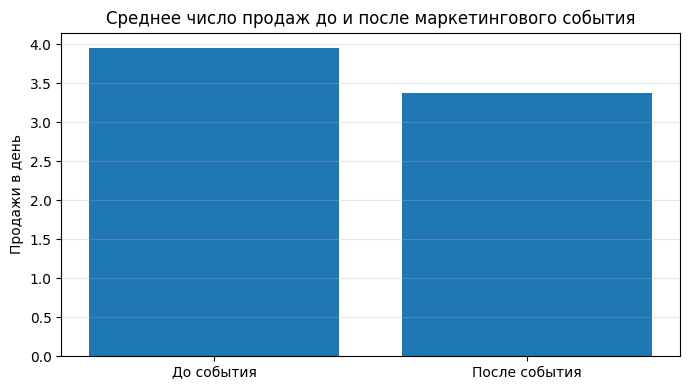

In [182]:
plt.figure(figsize=(7, 4))

plt.bar(
    overall["period"],
    overall["transactions"]
)

plt.title("Среднее число продаж до и после маркетингового события")
plt.ylabel("Продажи в день")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

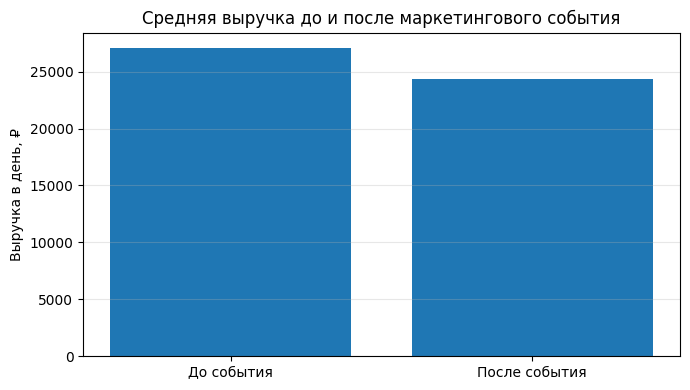

In [183]:
plt.figure(figsize=(7, 4))

plt.bar(
    overall["period"],
    overall["revenue"]
)

plt.title("Средняя выручка до и после маркетингового события")
plt.ylabel("Выручка в день, ₽")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [184]:
activity_effect = (
    event_sales
    .groupby("activity_type", as_index=False)
    .agg(
        events=("event_id", "nunique"),
        avg_uplift_transactions=("uplift_transactions_abs", "mean"),
        median_uplift_transactions=("uplift_transactions_abs", "median"),
        avg_uplift_revenue=("uplift_revenue_abs", "mean")
    )
    .sort_values("avg_uplift_revenue", ascending=False)
)

display(activity_effect)

,activity_type,events,avg_uplift_transactions,median_uplift_transactions,avg_uplift_revenue
2,Контент с предложением курсов,40,0.63,0.67,"5,163.59"
5,Прочий контент,1,-0.33,-0.33,"-1,498.33"
3,Контент с упоминанием,7,-0.00,-0.33,"-1,684.04"
0,Бесплатное событие / лид-магнит,1,-0.33,-0.33,"-2,158.33"
1,Запуск / набор,7,-1.07,-1.17,"-8,762.85"
4,Промо со скидкой,26,-2.15,-5.67,"-11,400.76"


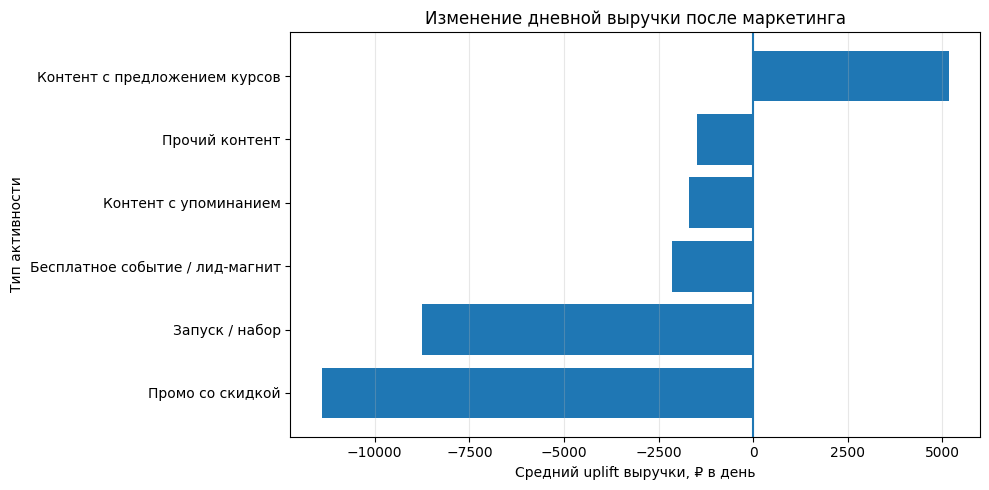

In [185]:
plot_data = activity_effect.sort_values("avg_uplift_revenue")

plt.figure(figsize=(10, 5))

plt.barh(
    plot_data["activity_type"],
    plot_data["avg_uplift_revenue"]
)

plt.axvline(0)

plt.title("Изменение дневной выручки после маркетинга")
plt.xlabel("Средний uplift выручки, ₽ в день")
plt.ylabel("Тип активности")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [186]:
course_effect = (
    event_sales
    .groupby("candidate_course", as_index=False)
    .agg(
        events=("event_id", "nunique"),
        avg_before=("avg_transactions_before", "mean"),
        avg_after=("avg_transactions_after", "mean"),
        avg_uplift_transactions=("uplift_transactions_abs", "mean"),
        avg_uplift_revenue=("uplift_revenue_abs", "mean")
    )
    .sort_values("avg_uplift_transactions", ascending=False)
)

display(course_effect)

,candidate_course,events,avg_before,avg_after,avg_uplift_transactions,avg_uplift_revenue
3,ML про,36,3.53,4.25,0.72,"5,763.33"
5,А/В-тесты,5,0.20,0.20,0.00,298.67
6,Алгоритмы про,37,1.45,1.44,-0.01,260.01
8,Аналитика про,37,4.11,4.08,-0.03,215.38
1,Backend про,39,2.48,2.23,-0.25,"-1,967.37"
0,AI-агенты про,38,3.94,3.64,-0.30,"-2,875.07"
4,ML старт,18,6.56,5.69,-0.87,"-2,784.26"
9,Аналитика старт,21,5.08,4.21,-0.87,"-3,012.46"
7,Алгоритмы старт,20,8.87,5.87,-3.00,"-14,192.75"
2,Backend старт,19,4.47,1.07,-3.40,"-20,284.85"


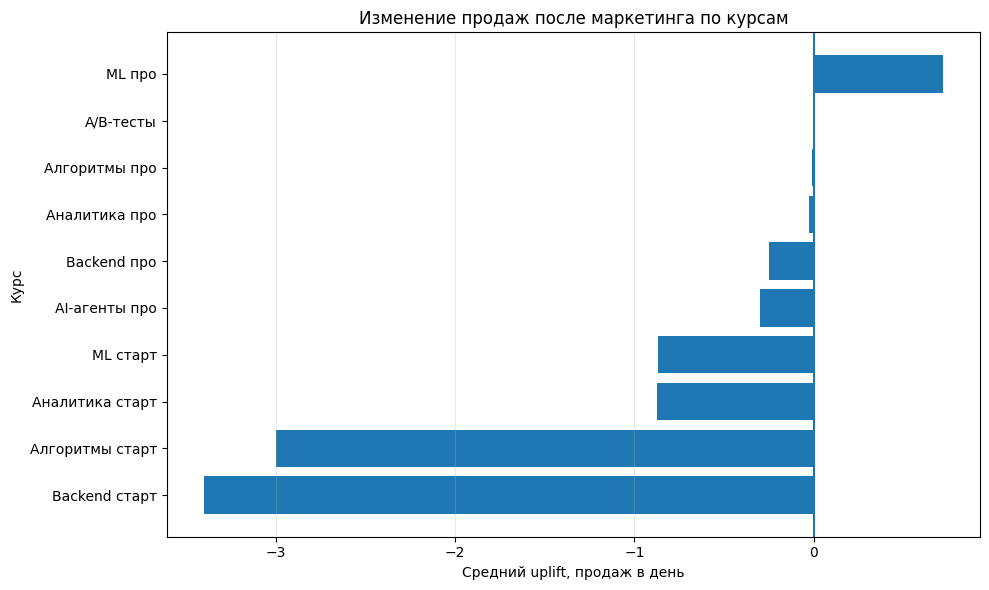

In [187]:
plot_data = course_effect.sort_values("avg_uplift_transactions")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["candidate_course"],
    plot_data["avg_uplift_transactions"]
)

plt.axvline(0)

plt.title("Изменение продаж после маркетинга по курсам")
plt.xlabel("Средний uplift, продаж в день")
plt.ylabel("Курс")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [188]:
line_effect = (
    event_sales
    .dropna(subset=["product_line"])
    .groupby("product_line", as_index=False)
    .agg(
        events=("event_id", "nunique"),
        avg_before=("avg_transactions_before", "mean"),
        avg_after=("avg_transactions_after", "mean"),
        avg_uplift_transactions=("uplift_transactions_abs", "mean"),
        avg_uplift_revenue=("uplift_revenue_abs", "mean")
    )
)

display(line_effect)

,product_line,events,avg_before,avg_after,avg_uplift_transactions,avg_uplift_revenue
0,PRO,53,3.08,3.04,-0.04,-306.80
1,START,24,6.36,4.24,-2.12,"-10,514.63"
2,START | PRO,3,1.81,3.90,2.10,"16,780.48"


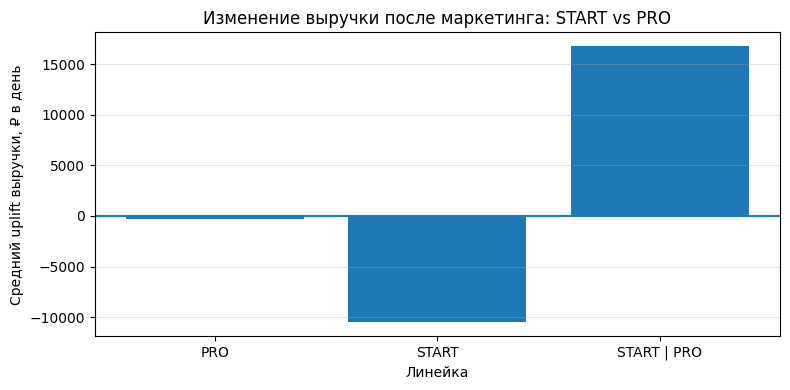

In [189]:
plt.figure(figsize=(8, 4))

plt.bar(
    line_effect["product_line"],
    line_effect["avg_uplift_revenue"]
)

plt.axhline(0)

plt.title("Изменение выручки после маркетинга: START vs PRO")
plt.xlabel("Линейка")
plt.ylabel("Средний uplift выручки, ₽ в день")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [190]:
positive_share = (
    (event_sales["uplift_transactions_abs"] > 0)
    .mean()
    * 100
)

print(
    f"Доля событий, после которых продажи выросли: "
    f"{positive_share:.1f}%"
)

Доля событий, после которых продажи выросли: 43.7%


In [191]:
positive_revenue_share = (
    (event_sales["uplift_revenue_abs"] > 0)
    .mean()
    * 100
)

print(
    f"Доля событий, после которых выросла выручка: "
    f"{positive_revenue_share:.1f}%"
)

Доля событий, после которых выросла выручка: 48.1%


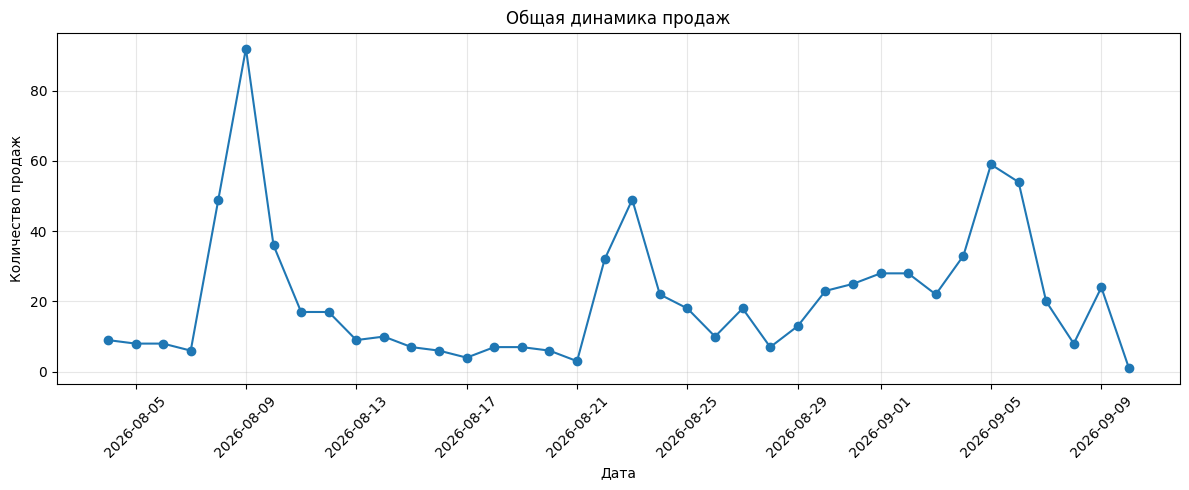

In [192]:
daily_total = (
    sales
    .assign(date=sales["timestamp"].dt.floor("D"))
    .groupby("date", as_index=False)
    .agg(
        transactions=("student_id", "size"),
        revenue=("amount", "sum")
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    daily_total["date"],
    daily_total["transactions"],
    marker="o"
)

ax.set_title("Общая динамика продаж")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество продаж")
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [193]:
def get_product_line(course):
    course = str(course).lower()

    if "старт" in course:
        return "START"

    if "про" in course or "ai-агенты" in course:
        return "PRO"

    return "OTHER"

sales["product_line"] = (
    sales["course_normalized"]
    .apply(get_product_line)
)

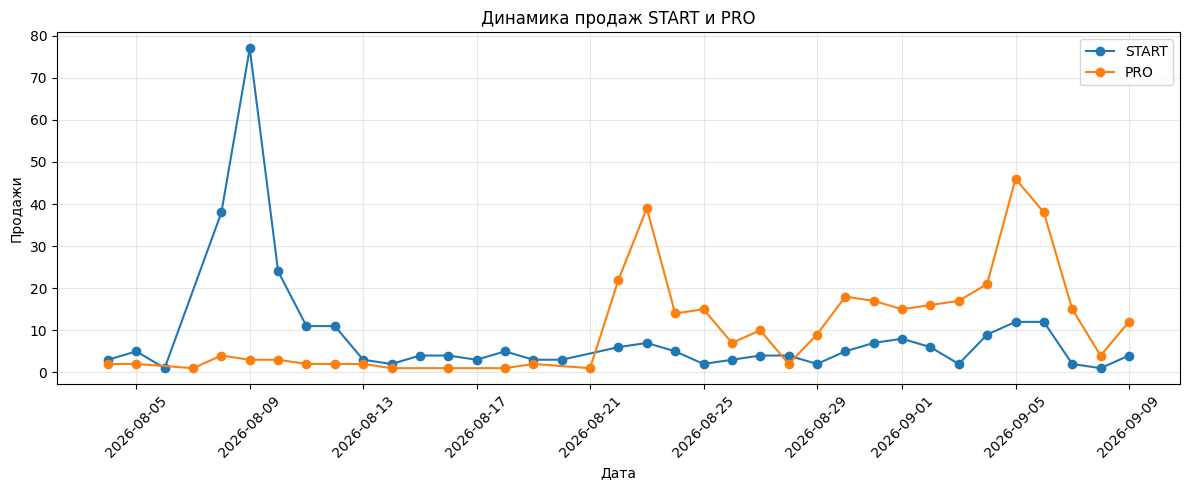

In [194]:
daily_line = (
    sales
    .assign(date=sales["timestamp"].dt.floor("D"))
    .groupby(
        ["date", "product_line"],
        as_index=False
    )
    .agg(
        transactions=("student_id", "size")
    )
)

fig, ax = plt.subplots(figsize=(12, 5))

for line in ["START", "PRO"]:
    subset = daily_line[
        daily_line["product_line"] == line
    ]

    ax.plot(
        subset["date"],
        subset["transactions"],
        marker="o",
        label=line
    )

ax.set_title("Динамика продаж START и PRO")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [195]:
events_daily = (
    marketing_courses
    .assign(date=marketing_courses["event_time"].dt.floor("D"))
    .groupby("date")
    .agg(
        events=("event_id", "nunique"),
        course_mentions=("candidate_course", "size")
    )
    .reset_index()
)

events_daily.sort_values(
    "events",
    ascending=False
).head(15)

,date,events,course_mentions
4,2026-08-10,13,46
10,2026-08-23,7,12
24,2026-09-07,6,12
21,2026-09-03,6,23
2,2026-08-08,5,18
20,2026-09-02,5,21
23,2026-09-06,4,16
16,2026-08-29,3,15
3,2026-08-09,3,9
9,2026-08-22,3,8


In [196]:
marketing_course_daily = (
    marketing_courses
    .assign(date=marketing_courses["event_time"].dt.floor("D"))
    .groupby(
        ["date", "candidate_course"],
        as_index=False
    )
    .agg(
        marketing_events=("event_id", "nunique"),
        activity_types=(
            "activity_type",
            lambda x: " | ".join(sorted(set(x.dropna())))
        )
    )
)

marketing_course_daily.head()

,date,candidate_course,marketing_events,activity_types
0,2026-08-05,AI-агенты про,1,Контент с предложением курсов
1,2026-08-05,Backend про,1,Контент с предложением курсов
2,2026-08-05,ML про,1,Контент с предложением курсов
3,2026-08-05,Алгоритмы про,1,Контент с предложением курсов
4,2026-08-05,Аналитика про,1,Контент с предложением курсов


In [197]:
marketing_course_daily["marketing_events"].describe()

count   119.00
mean      2.27
std       2.06
min       1.00
25%       1.00
50%       2.00
75%       3.00
max      12.00
Name: marketing_events, dtype: float64

In [198]:
marketing_course_daily.sort_values(
    "marketing_events",
    ascending=False
).head(20)

,date,candidate_course,marketing_events,activity_types
18,2026-08-10,Аналитика старт,12,Промо со скидкой
17,2026-08-10,Алгоритмы старт,12,Промо со скидкой
16,2026-08-10,ML старт,11,Промо со скидкой
15,2026-08-10,Backend старт,11,Промо со скидкой
84,2026-09-02,AI-агенты про,5,Контент с предложением курсов
8,2026-08-08,ML старт,5,Промо со скидкой
89,2026-09-03,AI-агенты про,5,Контент с предложением курсов
9,2026-08-08,Алгоритмы старт,5,Промо со скидкой
87,2026-09-02,Алгоритмы про,5,Контент с предложением курсов
7,2026-08-08,Backend старт,4,Промо со скидкой


In [199]:
analysis_daily = marketing_course_daily.merge(
    sales_daily,
    left_on=["date", "candidate_course"],
    right_on=["date", "course_normalized"],
    how="left"
)

analysis_daily[
    ["date", "candidate_course", "marketing_events", "transactions", "revenue"]
].head(20)

,date,candidate_course,marketing_events,transactions,revenue
0,2026-08-05,AI-агенты про,1,NaN,NaN
1,2026-08-05,Backend про,1,2.00,"16,450.00"
2,2026-08-05,ML про,1,NaN,NaN
3,2026-08-05,Алгоритмы про,1,NaN,NaN
4,2026-08-05,Аналитика про,1,NaN,NaN
5,2026-08-07,ML про,1,1.00,"8,745.00"
6,2026-08-07,Алгоритмы старт,1,NaN,NaN
7,2026-08-08,Backend старт,4,8.00,"45,850.00"
8,2026-08-08,ML старт,5,9.00,"48,130.00"
9,2026-08-08,Алгоритмы старт,5,14.00,"72,565.00"


Маркетинговые события распределены по времени неравномерно и часто концентрируются в одни и те же даты. 
Например, 10.08 зафиксировано 13 маркетинговых событий и 46 упоминаний курсов.

Из-за этого простая схема «одно событие → продажи после него» приводит к сильному пересечению окон и многократному учёту одних и тех же продаж.

Поэтому дальнейший анализ проводится на уровне `дата × курс`, а не отдельного `event_id`.

In [200]:
LAG_BEFORE = 3
LAG_AFTER = 7

event_study_rows = []

for _, row in marketing_course_daily.iterrows():
    event_date = row["date"]
    course = row["candidate_course"]

    course_sales = sales_daily[
        sales_daily["course_normalized"] == course
    ]

    for lag in range(-LAG_BEFORE, LAG_AFTER + 1):
        target_date = event_date + pd.Timedelta(days=lag)

        day_sales = course_sales[
            course_sales["date"] == target_date
        ]

        if len(day_sales) > 0:
            transactions = day_sales["transactions"].sum()
            buyers = day_sales["buyers"].sum()
            revenue = day_sales["revenue"].sum()
        else:
            transactions = 0
            buyers = 0
            revenue = 0

        event_study_rows.append({
            "event_date": event_date,
            "candidate_course": course,
            "lag": lag,
            "marketing_events": row["marketing_events"],
            "transactions": transactions,
            "buyers": buyers,
            "revenue": revenue,
        })

event_study = pd.DataFrame(event_study_rows)

event_study.head(15)

,event_date,candidate_course,lag,marketing_events,transactions,buyers,revenue
0,2026-08-05,AI-агенты про,-3,1,0,0,0.00
1,2026-08-05,AI-агенты про,-2,1,0,0,0.00
2,2026-08-05,AI-агенты про,-1,1,0,0,0.00
3,2026-08-05,AI-агенты про,0,1,0,0,0.00
4,2026-08-05,AI-агенты про,1,1,0,0,0.00
5,2026-08-05,AI-агенты про,2,1,0,0,0.00
6,2026-08-05,AI-агенты про,3,1,0,0,0.00
7,2026-08-05,AI-агенты про,4,1,0,0,0.00
8,2026-08-05,AI-агенты про,5,1,0,0,0.00
9,2026-08-05,AI-агенты про,6,1,0,0,0.00


In [201]:
event_study_summary = (
    event_study
    .groupby("lag", as_index=False)
    .agg(
        avg_transactions=("transactions", "mean"),
        median_transactions=("transactions", "median"),
        avg_buyers=("buyers", "mean"),
        avg_revenue=("revenue", "mean"),
        observations=("candidate_course", "size"),
    )
)

event_study_summary

,lag,avg_transactions,median_transactions,avg_buyers,avg_revenue,observations
0,-3,2.21,1.00,2.21,"17,414.19",119
1,-2,2.67,1.00,2.67,"20,574.17",119
2,-1,3.39,1.00,3.39,"24,346.64",119
3,0,3.82,2.00,3.82,"27,368.51",119
4,1,3.27,2.00,3.27,"23,294.33",119
5,2,2.58,1.00,2.58,"19,268.76",119
6,3,2.34,1.00,2.34,"18,018.42",119
7,4,2.18,1.00,2.18,"17,072.92",119
8,5,2.02,1.00,2.02,"15,885.74",119
9,6,2.15,1.00,2.15,"16,983.28",119


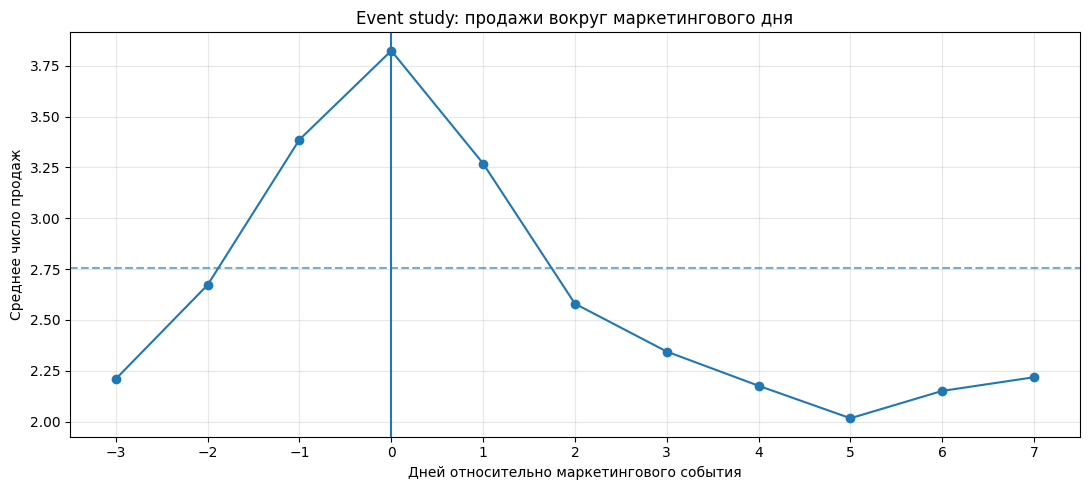

In [202]:
plt.figure(figsize=(11, 5))

plt.plot(
    event_study_summary["lag"],
    event_study_summary["avg_transactions"],
    marker="o"
)

plt.axvline(0)
plt.axhline(
    event_study_summary.loc[
        event_study_summary["lag"] < 0,
        "avg_transactions"
    ].mean(),
    linestyle="--",
    alpha=0.6
)

plt.title("Event study: продажи вокруг маркетингового дня")
plt.xlabel("Дней относительно маркетингового события")
plt.ylabel("Среднее число продаж")
plt.xticks(range(-LAG_BEFORE, LAG_AFTER + 1))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

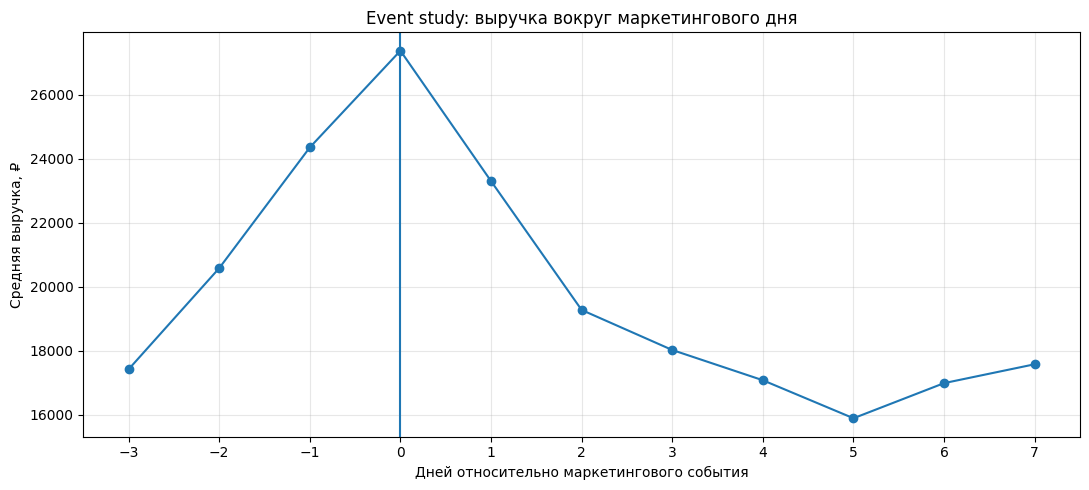

In [203]:
plt.figure(figsize=(11, 5))

plt.plot(
    event_study_summary["lag"],
    event_study_summary["avg_revenue"],
    marker="o"
)

plt.axvline(0)

plt.title("Event study: выручка вокруг маркетингового дня")
plt.xlabel("Дней относительно маркетингового события")
plt.ylabel("Средняя выручка, ₽")
plt.xticks(range(-LAG_BEFORE, LAG_AFTER + 1))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [204]:
baseline_transactions = (
    event_study_summary.loc[
        event_study_summary["lag"] < 0,
        "avg_transactions"
    ]
    .mean()
)

baseline_revenue = (
    event_study_summary.loc[
        event_study_summary["lag"] < 0,
        "avg_revenue"
    ]
    .mean()
)

baseline_transactions, baseline_revenue

(2.756302521008404, 20778.332408963586)

In [205]:
event_study_summary["transactions_index"] = (
    event_study_summary["avg_transactions"]
    / baseline_transactions
    * 100
)

event_study_summary["revenue_index"] = (
    event_study_summary["avg_revenue"]
    / baseline_revenue
    * 100
)

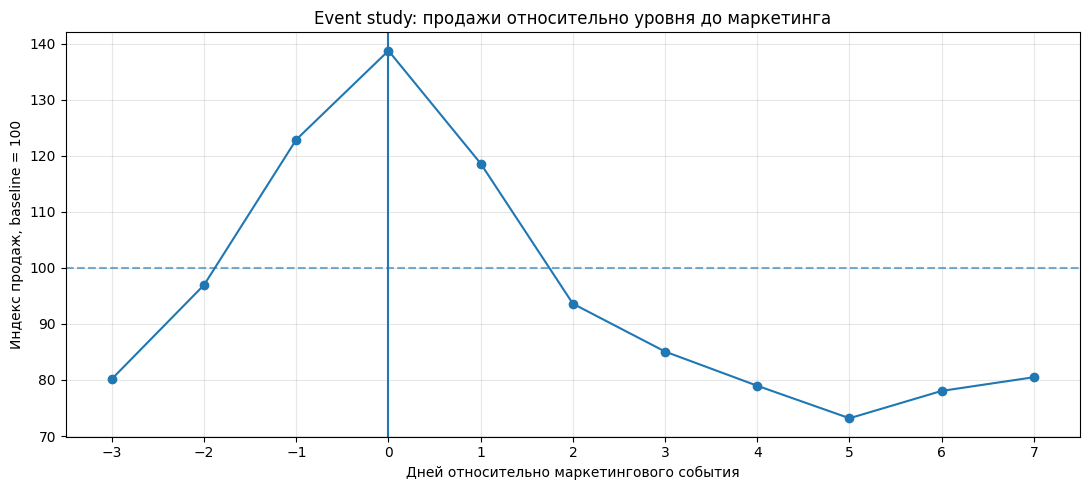

In [206]:
plt.figure(figsize=(11, 5))

plt.plot(
    event_study_summary["lag"],
    event_study_summary["transactions_index"],
    marker="o"
)

plt.axhline(100, linestyle="--", alpha=0.6)
plt.axvline(0)

plt.title("Event study: продажи относительно уровня до маркетинга")
plt.xlabel("Дней относительно маркетингового события")
plt.ylabel("Индекс продаж, baseline = 100")
plt.xticks(range(-LAG_BEFORE, LAG_AFTER + 1))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Вывод

В среднем продажи начинают расти ещё до зафиксированного маркетингового события,
достигают максимума в день события (`D0`) и остаются повышенными на следующий день (`D+1`).
После `D+1` наблюдается снижение продаж.

При этом наличие роста уже на `D-1` указывает на выраженный pre-trend.
Поэтому пик в `D0` нельзя интерпретировать как причинный эффект одного конкретного
маркетингового события.

Вероятные причины — пересечение нескольких маркетинговых активностей,
предшествующий прогрев аудитории и концентрация событий в одни и те же даты.

## 5. Event study по продуктовым линейкам

Общий event study показал, что продажи начинают расти ещё до маркетингового события,
достигают пика в день события и затем снижаются.

Теперь проверим, одинаково ли ведут себя продукты START и PRO.
Это важно, потому что средний график может скрывать разные паттерны реакции
для разных продуктовых линеек.

In [207]:
# Добавляем product_line к каждой паре event_date × course
event_study_with_line = event_study.merge(
    marketing_course_daily[
        ["date", "candidate_course"]
    ].drop_duplicates(),
    left_on=["event_date", "candidate_course"],
    right_on=["date", "candidate_course"],
    how="left"
)

# Берём product_line из исходной таблицы marketing_courses
course_line_map = (
    marketing_courses[
        ["candidate_course", "product_line"]
    ]
    .dropna()
    .drop_duplicates()
)

event_study_with_line = event_study_with_line.merge(
    course_line_map,
    on="candidate_course",
    how="left"
)

event_study_with_line.head()

,event_date,candidate_course,lag,marketing_events,transactions,buyers,revenue,date,product_line
0,2026-08-05,AI-агенты про,-3,1,0,0,0.00,2026-08-05,PRO
1,2026-08-05,AI-агенты про,-2,1,0,0,0.00,2026-08-05,PRO
2,2026-08-05,AI-агенты про,-1,1,0,0,0.00,2026-08-05,PRO
3,2026-08-05,AI-агенты про,0,1,0,0,0.00,2026-08-05,PRO
4,2026-08-05,AI-агенты про,1,1,0,0,0.00,2026-08-05,PRO


In [208]:
line_event_study = (
    event_study_with_line
    .dropna(subset=["product_line"])
    .groupby(
        ["product_line", "lag"],
        as_index=False
    )
    .agg(
        avg_transactions=("transactions", "mean"),
        avg_revenue=("revenue", "mean"),
        observations=("candidate_course", "size")
    )
)

line_event_study.head()

,product_line,lag,avg_transactions,avg_revenue,observations
0,PRO,-3,2.50,"19,663.55",102
1,PRO,-2,2.66,"21,215.99",102
2,PRO,-1,2.75,"21,750.87",102
3,PRO,0,3.07,"24,291.53",102
4,PRO,1,2.50,"19,839.63",102


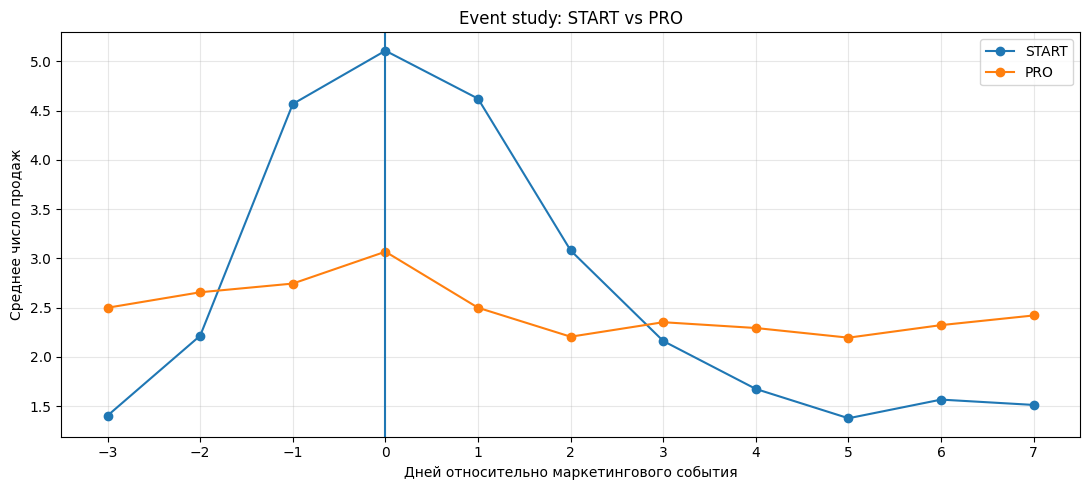

In [209]:
plt.figure(figsize=(11, 5))

for line in ["START", "PRO"]:
    subset = line_event_study[
        line_event_study["product_line"] == line
    ]

    plt.plot(
        subset["lag"],
        subset["avg_transactions"],
        marker="o",
        label=line
    )

plt.axvline(0)
plt.title("Event study: START vs PRO")
plt.xlabel("Дней относительно маркетингового события")
plt.ylabel("Среднее число продаж")
plt.xticks(range(-3, 8))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Вывод

START и PRO демонстрируют разные паттерны продаж вокруг маркетинговых активностей.

Для START наблюдается выраженный рост продаж перед событием, пик в день события и быстрое снижение после него. Это похоже на эффект общей кампании или прогрева, а не одного отдельного поста.

Для PRO продажи ведут себя значительно стабильнее: пик в D0 есть, но он гораздо слабее, а общий уровень продаж меняется меньше.

Таким образом, START сильнее связан с краткосрочными маркетинговыми периодами, тогда как PRO показывает более ровную динамику спроса.

## 6. Event study по типу маркетинговой активности

Теперь проверим, отличаются ли паттерны продаж в зависимости от типа активности.

Например, запуск курса, скидка и обычный промо-пост могут иметь совершенно разный
временной профиль влияния на продажи.

In [210]:
# Для каждой пары дата × курс собираем список типов активностей
activity_daily = (
    marketing_courses
    .assign(date=marketing_courses["event_time"].dt.floor("D"))
    .groupby(
        ["date", "candidate_course"],
        as_index=False
    )
    .agg(
        activity_types=(
            "activity_type",
            lambda x: " | ".join(sorted(set(x.dropna())))
        )
    )
)

activity_daily.head()

,date,candidate_course,activity_types
0,2026-08-05,AI-агенты про,Контент с предложением курсов
1,2026-08-05,Backend про,Контент с предложением курсов
2,2026-08-05,ML про,Контент с предложением курсов
3,2026-08-05,Алгоритмы про,Контент с предложением курсов
4,2026-08-05,Аналитика про,Контент с предложением курсов


In [211]:
event_study_activity = event_study.merge(
    activity_daily,
    left_on=["event_date", "candidate_course"],
    right_on=["date", "candidate_course"],
    how="left"
)

event_study_activity.head()

,event_date,candidate_course,lag,marketing_events,transactions,buyers,revenue,date,activity_types
0,2026-08-05,AI-агенты про,-3,1,0,0,0.00,2026-08-05,Контент с предложением курсов
1,2026-08-05,AI-агенты про,-2,1,0,0,0.00,2026-08-05,Контент с предложением курсов
2,2026-08-05,AI-агенты про,-1,1,0,0,0.00,2026-08-05,Контент с предложением курсов
3,2026-08-05,AI-агенты про,0,1,0,0,0.00,2026-08-05,Контент с предложением курсов
4,2026-08-05,AI-агенты про,1,1,0,0,0.00,2026-08-05,Контент с предложением курсов


In [212]:
# Исключаем смешанные дни, где одновременно было несколько activity_type
event_study_activity_clean = event_study_activity[
    ~event_study_activity["activity_types"].str.contains(
        r"\|",
        regex=True,
        na=False
    )
].copy()

event_study_activity_clean["activity_types"].value_counts()

activity_types
Контент с предложением курсов      550
Запуск / набор                     209
Промо со скидкой                   187
Контент с упоминанием              165
Прочий контент                      11
Бесплатное событие / лид-магнит     11
Name: count, dtype: int64

In [213]:
activity_event_study = (
    event_study_activity_clean
    .groupby(
        ["activity_types", "lag"],
        as_index=False
    )
    .agg(
        avg_transactions=("transactions", "mean"),
        avg_revenue=("revenue", "mean"),
        observations=("candidate_course", "size")
    )
)

activity_event_study.head()

,activity_types,lag,avg_transactions,avg_revenue,observations
0,Бесплатное событие / лид-магнит,-3,0.00,0.00,1
1,Бесплатное событие / лид-магнит,-2,1.00,"6,475.00",1
2,Бесплатное событие / лид-магнит,-1,0.00,0.00,1
3,Бесплатное событие / лид-магнит,0,0.00,0.00,1
4,Бесплатное событие / лид-магнит,1,0.00,0.00,1


In [214]:
activity_counts = (
    event_study_activity_clean[
        ["event_date", "candidate_course", "activity_types"]
    ]
    .drop_duplicates()
    ["activity_types"]
    .value_counts()
)

activity_counts

activity_types
Контент с предложением курсов      50
Запуск / набор                     19
Промо со скидкой                   17
Контент с упоминанием              15
Прочий контент                      1
Бесплатное событие / лид-магнит     1
Name: count, dtype: int64

In [215]:
valid_activities = activity_counts[
    activity_counts >= 5
].index

plot_activity = activity_event_study[
    activity_event_study["activity_types"].isin(valid_activities)
]

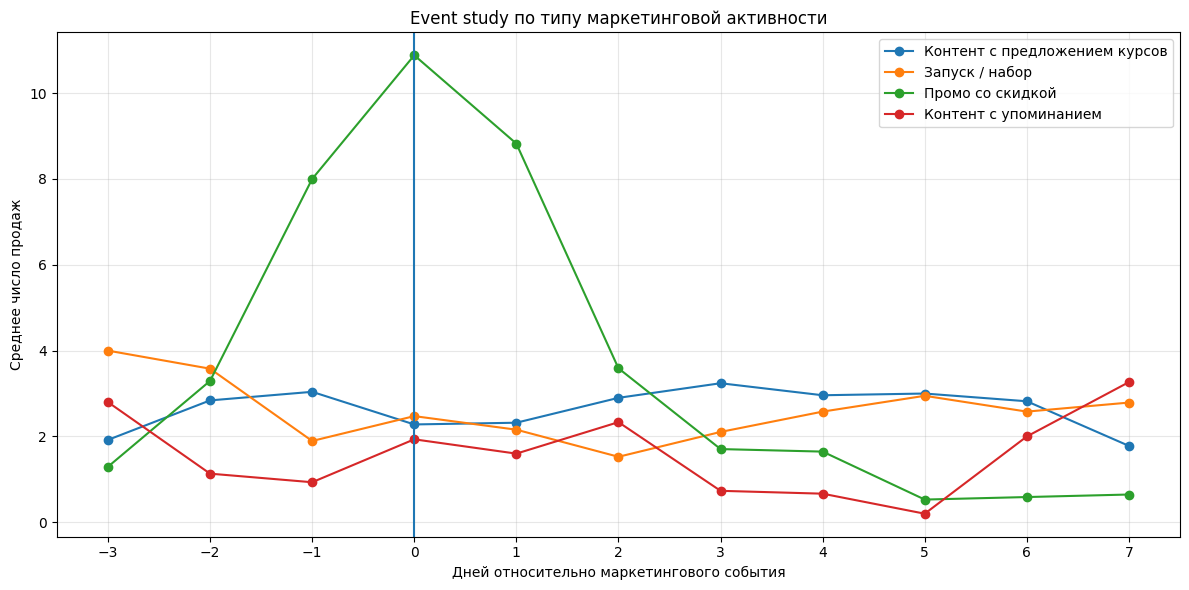

In [216]:
plt.figure(figsize=(12, 6))

for activity in valid_activities:
    subset = plot_activity[
        plot_activity["activity_types"] == activity
    ]

    plt.plot(
        subset["lag"],
        subset["avg_transactions"],
        marker="o",
        label=activity
    )

plt.axvline(0)
plt.title("Event study по типу маркетинговой активности")
plt.xlabel("Дней относительно маркетингового события")
plt.ylabel("Среднее число продаж")
plt.xticks(range(-3, 8))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Вывод

После уточнения классификации маркетинговых активностей различия между типами стали заметнее.

Самый выраженный паттерн наблюдается для промо со скидкой:
продажи начинают резко расти ещё за день до события, достигают максимума в D0
и остаются высокими в D+1, после чего быстро снижаются.

Это похоже на краткосрочную промо-кампанию с предварительным прогревом аудитории.

Контент с предложением курсов показывает более стабильную динамику без сильного пика,
а для запуска / набора и контента с упоминанием эффект выражен слабее и требует
проверки количества наблюдений.

## 8. Проверка количества наблюдений по типам активности

Event study по типам активности показал заметные различия между категориями.

Однако средние значения могут быть нестабильными, если какой-то тип активности
встречается всего несколько раз. Поэтому перед интерпретацией графика проверим,
сколько уникальных маркетинговых дней приходится на каждый тип активности.

In [217]:
# Считаем количество уникальных комбинаций:
# маркетинговая дата × курс × тип активности

activity_counts = (
    event_study_activity_clean[
        ["event_date", "candidate_course", "activity_types"]
    ]
    .drop_duplicates()
    .groupby("activity_types")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="observations")
)

activity_counts

,activity_types,observations
0,Контент с предложением курсов,50
1,Запуск / набор,19
2,Промо со скидкой,17
3,Контент с упоминанием,15
4,Бесплатное событие / лид-магнит,1
5,Прочий контент,1


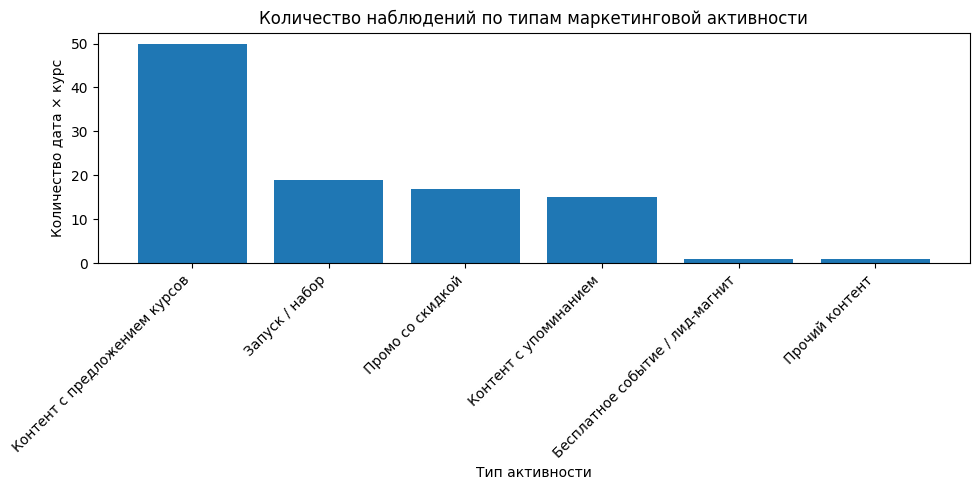

In [218]:
plt.figure(figsize=(10, 5))

plt.bar(
    activity_counts["activity_types"],
    activity_counts["observations"]
)

plt.title("Количество наблюдений по типам маркетинговой активности")
plt.xlabel("Тип активности")
plt.ylabel("Количество дата × курс")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Вывод

Четыре основных типа маркетинговой активности имеют достаточное количество
наблюдений для сравнительного анализа.

Наиболее представлен «Контент с предложением курсов» — около 50 наблюдений.
Для запуска / набора, промо со скидкой и контента с упоминанием выборки меньше,
но всё ещё позволяют рассматривать их как отдельные группы.

Категории с единичными наблюдениями далее отдельно не интерпретируются.

## 9. Сравнение продаж до события, в D0 и D+1

Для каждого типа маркетинговой активности сравним:

- baseline — средние продажи за D-3, D-2 и D-1;
- продажи в день события D0;
- продажи на следующий день D+1.

Так можно количественно оценить, насколько продажи около маркетингового события
отличаются от уровня непосредственно перед ним.

In [219]:
# Средние продажи до события: D-3 ... D-1
baseline_by_activity = (
    event_study_activity_clean[
        event_study_activity_clean["lag"].between(-3, -1)
    ]
    .groupby("activity_types", as_index=False)
    .agg(
        baseline_transactions=("transactions", "mean"),
        baseline_revenue=("revenue", "mean")
    )
)

# Продажи в D0
d0_by_activity = (
    event_study_activity_clean[
        event_study_activity_clean["lag"] == 0
    ]
    .groupby("activity_types", as_index=False)
    .agg(
        d0_transactions=("transactions", "mean"),
        d0_revenue=("revenue", "mean")
    )
)

# Продажи в D+1
d1_by_activity = (
    event_study_activity_clean[
        event_study_activity_clean["lag"] == 1
    ]
    .groupby("activity_types", as_index=False)
    .agg(
        d1_transactions=("transactions", "mean"),
        d1_revenue=("revenue", "mean")
    )
)

activity_comparison = (
    baseline_by_activity
    .merge(d0_by_activity, on="activity_types", how="outer")
    .merge(d1_by_activity, on="activity_types", how="outer")
)

activity_comparison

,activity_types,baseline_transactions,baseline_revenue,d0_transactions,d0_revenue,d1_transactions,d1_revenue
0,Бесплатное событие / лид-магнит,0.33,"2,158.33",0.00,0.00,0.00,0.00
1,Запуск / набор,3.16,"25,254.28",2.47,"19,220.39",2.16,"17,313.82"
2,Контент с предложением курсов,2.60,"20,587.78",2.28,"18,065.89",2.32,"18,541.46"
3,Контент с упоминанием,1.62,"12,221.33",1.93,"15,184.67",1.60,"10,548.67"
4,Промо со скидкой,4.20,"25,797.97",10.88,"67,279.45",8.82,"52,746.86"
5,Прочий контент,0.33,"1,498.33",0.00,0.00,0.00,0.00


In [220]:
# Считаем изменение D0 и D+1 относительно baseline

activity_comparison["d0_vs_baseline_pct"] = (
    (
        activity_comparison["d0_transactions"]
        / activity_comparison["baseline_transactions"]
        - 1
    ) * 100
)

activity_comparison["d1_vs_baseline_pct"] = (
    (
        activity_comparison["d1_transactions"]
        / activity_comparison["baseline_transactions"]
        - 1
    ) * 100
)

activity_comparison.sort_values(
    "d0_vs_baseline_pct",
    ascending=False
)

,activity_types,baseline_transactions,baseline_revenue,d0_transactions,d0_revenue,d1_transactions,d1_revenue,d0_vs_baseline_pct,d1_vs_baseline_pct
4,Промо со скидкой,4.20,"25,797.97",10.88,"67,279.45",8.82,"52,746.86",159.35,110.28
3,Контент с упоминанием,1.62,"12,221.33",1.93,"15,184.67",1.60,"10,548.67",19.18,-1.37
2,Контент с предложением курсов,2.60,"20,587.78",2.28,"18,065.89",2.32,"18,541.46",-12.31,-10.77
1,Запуск / набор,3.16,"25,254.28",2.47,"19,220.39",2.16,"17,313.82",-21.67,-31.67
0,Бесплатное событие / лид-магнит,0.33,"2,158.33",0.00,0.00,0.00,0.00,-100.00,-100.00
5,Прочий контент,0.33,"1,498.33",0.00,0.00,0.00,0.00,-100.00,-100.00


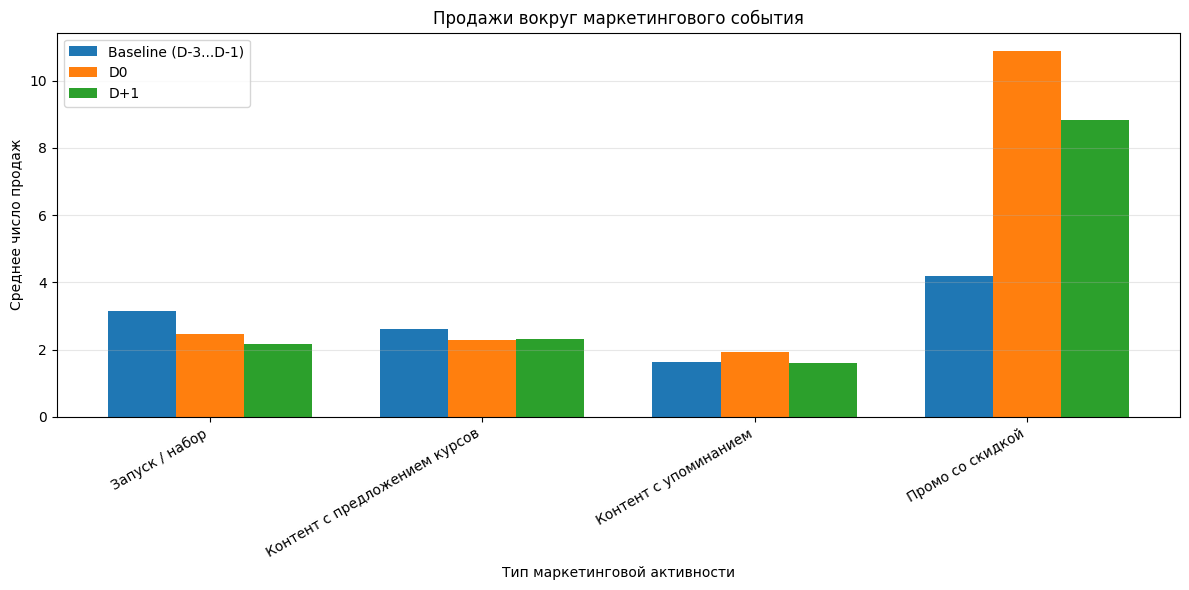

In [221]:
# Оставляем только четыре типа с достаточным количеством наблюдений
main_activities = [
    "Контент с предложением курсов",
    "Запуск / набор",
    "Промо со скидкой",
    "Контент с упоминанием"
]

plot_comparison = activity_comparison[
    activity_comparison["activity_types"].isin(main_activities)
].copy()

# Подготавливаем положение столбцов
x = np.arange(len(plot_comparison))
width = 0.25

plt.figure(figsize=(12, 6))

# Средний уровень до маркетингового события
plt.bar(
    x - width,
    plot_comparison["baseline_transactions"],
    width,
    label="Baseline (D-3...D-1)"
)

# Продажи в день события
plt.bar(
    x,
    plot_comparison["d0_transactions"],
    width,
    label="D0"
)

# Продажи на следующий день
plt.bar(
    x + width,
    plot_comparison["d1_transactions"],
    width,
    label="D+1"
)

plt.title("Продажи вокруг маркетингового события")
plt.xlabel("Тип маркетинговой активности")
plt.ylabel("Среднее число продаж")

plt.xticks(
    x,
    plot_comparison["activity_types"],
    rotation=30,
    ha="right"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

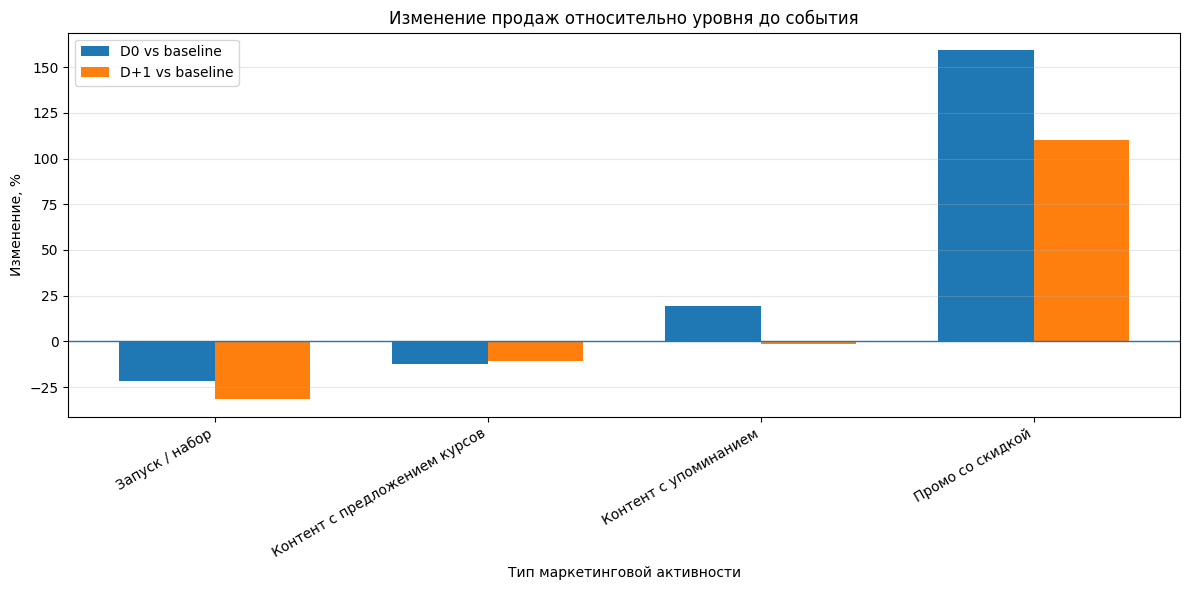

In [222]:
# Положение столбцов
x = np.arange(len(plot_comparison))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    plot_comparison["d0_vs_baseline_pct"],
    width,
    label="D0 vs baseline"
)

plt.bar(
    x + width / 2,
    plot_comparison["d1_vs_baseline_pct"],
    width,
    label="D+1 vs baseline"
)

# Нулевая линия означает отсутствие изменения относительно baseline
plt.axhline(0, linewidth=1)

plt.title("Изменение продаж относительно уровня до события")
plt.xlabel("Тип маркетинговой активности")
plt.ylabel("Изменение, %")

plt.xticks(
    x,
    plot_comparison["activity_types"],
    rotation=30,
    ha="right"
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Вывод

Наиболее выраженная связь с краткосрочным ростом продаж наблюдается у промо со скидкой.

В день скидочного промо среднее число продаж примерно в 2.6 раза выше baseline,
а на следующий день остаётся примерно в 2.1 раза выше уровня до события.

Для запуска / набора и контента с предложением курсов продажи в D0 и D+1
не превышают baseline. Вероятно, их эффект более растянут во времени
или связан с предварительным прогревом аудитории.

Контент с упоминанием показывает небольшой краткосрочный рост в D0,
который практически исчезает уже на следующий день.

Важно: эти различия отражают наблюдаемую связь, а не доказанный причинный эффект.
Маркетинговые активности могут пересекаться, а рост спроса часто начинается ещё до D0.

## 10. Интенсивность маркетинга и продажи

Ранее мы увидели, что маркетинговые активности часто концентрируются в одни и те же даты.

Теперь проверим, связана ли интенсивность маркетинга с продажами:
сравним дни, когда по конкретному курсу было 1, 2–3 или 4+ маркетинговых событий.

Это позволит понять, есть ли связь между количеством коммуникаций вокруг курса
и уровнем продаж.

In [223]:
# Разбиваем маркетинговые дни на группы по количеству событий
marketing_course_daily["intensity_group"] = pd.cut(
    marketing_course_daily["marketing_events"],
    bins=[0, 1, 3, np.inf],
    labels=[
        "1 событие",
        "2–3 события",
        "4+ событий"
    ]
)

# Смотрим, сколько наблюдений в каждой группе
intensity_counts = (
    marketing_course_daily["intensity_group"]
    .value_counts()
    .sort_index()
)

intensity_counts

intensity_group
1 событие      54
2–3 события    48
4+ событий     17
Name: count, dtype: int64

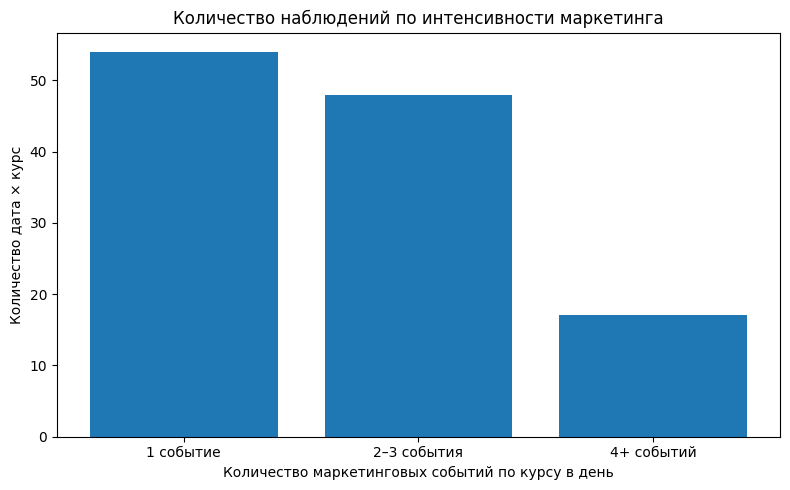

In [224]:
plt.figure(figsize=(8, 5))

plt.bar(
    intensity_counts.index.astype(str),
    intensity_counts.values
)

plt.title("Количество наблюдений по интенсивности маркетинга")
plt.xlabel("Количество маркетинговых событий по курсу в день")
plt.ylabel("Количество дата × курс")

plt.tight_layout()
plt.show()

In [225]:
# Добавляем группу интенсивности к event study
event_study_intensity = event_study.merge(
    marketing_course_daily[
        [
            "date",
            "candidate_course",
            "marketing_events",
            "intensity_group"
        ]
    ],
    left_on=["event_date", "candidate_course"],
    right_on=["date", "candidate_course"],
    how="left"
)

event_study_intensity.head()

,event_date,candidate_course,lag,marketing_events_x,transactions,buyers,revenue,date,marketing_events_y,intensity_group
0,2026-08-05,AI-агенты про,-3,1,0,0,0.00,2026-08-05,1,1 событие
1,2026-08-05,AI-агенты про,-2,1,0,0,0.00,2026-08-05,1,1 событие
2,2026-08-05,AI-агенты про,-1,1,0,0,0.00,2026-08-05,1,1 событие
3,2026-08-05,AI-агенты про,0,1,0,0,0.00,2026-08-05,1,1 событие
4,2026-08-05,AI-агенты про,1,1,0,0,0.00,2026-08-05,1,1 событие


In [226]:
intensity_event_study = (
    event_study_intensity
    .groupby(
        ["intensity_group", "lag"],
        as_index=False,
        observed=True
    )
    .agg(
        avg_transactions=("transactions", "mean"),
        avg_revenue=("revenue", "mean"),
        observations=("transactions", "count")
    )
)

intensity_event_study.head()

,intensity_group,lag,avg_transactions,avg_revenue,observations
0,1 событие,-3,1.63,"12,631.06",54
1,1 событие,-2,1.44,"11,200.46",54
2,1 событие,-1,1.59,"12,287.69",54
3,1 событие,0,1.83,"14,230.22",54
4,1 событие,1,1.81,"13,950.58",54


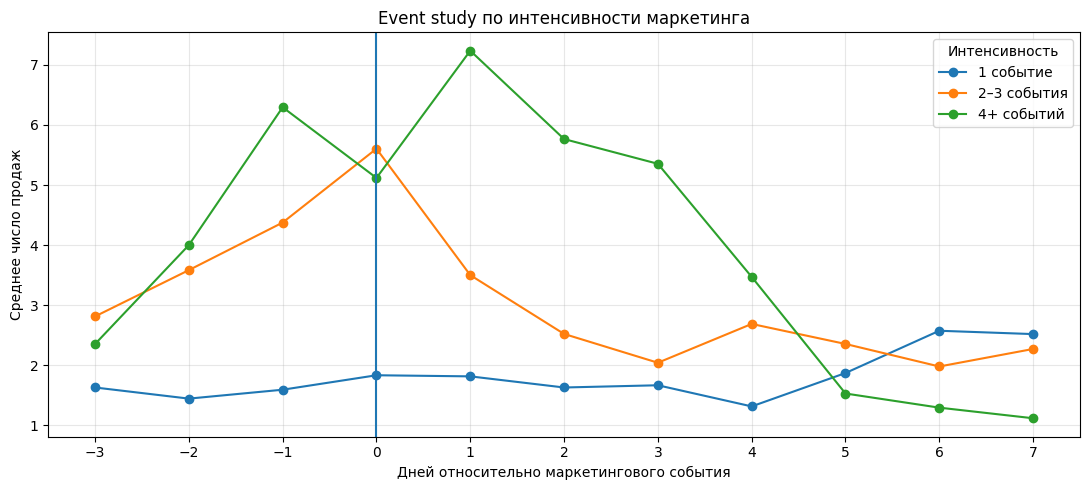

In [227]:
plt.figure(figsize=(11, 5))

for group in [
    "1 событие",
    "2–3 события",
    "4+ событий"
]:
    subset = intensity_event_study[
        intensity_event_study["intensity_group"] == group
    ]

    plt.plot(
        subset["lag"],
        subset["avg_transactions"],
        marker="o",
        label=group
    )

plt.axvline(0)

plt.title("Event study по интенсивности маркетинга")
plt.xlabel("Дней относительно маркетингового события")
plt.ylabel("Среднее число продаж")
plt.xticks(range(-3, 8))
plt.legend(title="Интенсивность")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [228]:
# Baseline: среднее число продаж за D-3...D-1
intensity_baseline = (
    event_study_intensity[
        event_study_intensity["lag"].between(-3, -1)
    ]
    .groupby("intensity_group", observed=True, as_index=False)
    .agg(
        baseline_transactions=("transactions", "mean")
    )
)

# D0
intensity_d0 = (
    event_study_intensity[
        event_study_intensity["lag"] == 0
    ]
    .groupby("intensity_group", observed=True, as_index=False)
    .agg(
        d0_transactions=("transactions", "mean")
    )
)

# D+1
intensity_d1 = (
    event_study_intensity[
        event_study_intensity["lag"] == 1
    ]
    .groupby("intensity_group", observed=True, as_index=False)
    .agg(
        d1_transactions=("transactions", "mean")
    )
)

intensity_comparison = (
    intensity_baseline
    .merge(intensity_d0, on="intensity_group")
    .merge(intensity_d1, on="intensity_group")
)

intensity_comparison

,intensity_group,baseline_transactions,d0_transactions,d1_transactions
0,1 событие,1.56,1.83,1.81
1,2–3 события,3.59,5.60,3.50
2,4+ событий,4.22,5.12,7.24


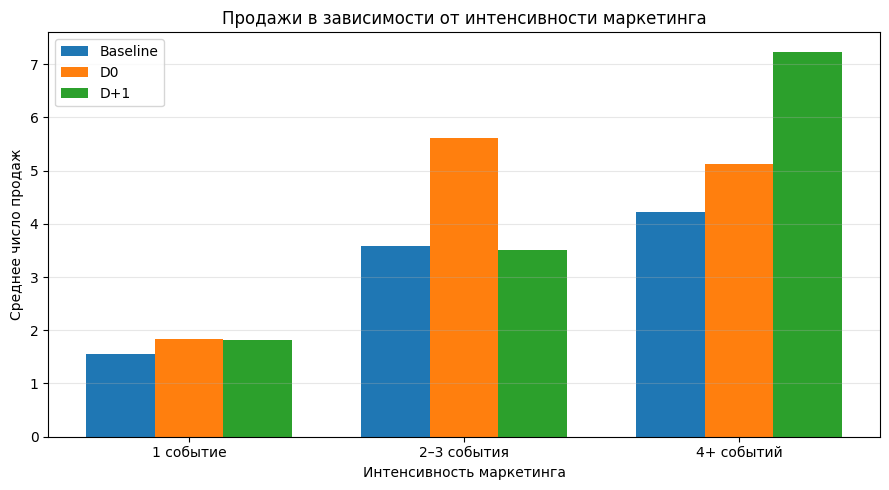

In [229]:
x = np.arange(len(intensity_comparison))
width = 0.25

plt.figure(figsize=(9, 5))

plt.bar(
    x - width,
    intensity_comparison["baseline_transactions"],
    width,
    label="Baseline"
)

plt.bar(
    x,
    intensity_comparison["d0_transactions"],
    width,
    label="D0"
)

plt.bar(
    x + width,
    intensity_comparison["d1_transactions"],
    width,
    label="D+1"
)

plt.title("Продажи в зависимости от интенсивности маркетинга")
plt.xlabel("Интенсивность маркетинга")
plt.ylabel("Среднее число продаж")

plt.xticks(
    x,
    intensity_comparison["intensity_group"].astype(str)
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Важно: это не доказывает причинный эффект количества публикаций.
В периоды высокого спроса команда могла сама увеличивать число маркетинговых активностей,
поэтому здесь мы фиксируем связь, а не причинность.

In [230]:
# Считаем количество наблюдений в каждой группе интенсивности маркетинга
# Наблюдение = одна комбинация дата × курс

intensity_counts = (
    marketing_course_daily
    .groupby("intensity_group", observed=True)
    .size()
    .reset_index(name="observations")
)

intensity_counts

,intensity_group,observations
0,1 событие,54
1,2–3 события,48
2,4+ событий,17


### Вывод

Во всех трёх группах достаточно наблюдений для сравнительного анализа:

- 1 событие — 54 наблюдения;
- 2–3 события — 48 наблюдений;
- 4+ событий — 17 наблюдений.

При увеличении маркетинговой интенсивности растёт и средний уровень продаж
вокруг маркетингового дня.

При одном событии изменение относительно baseline небольшое.
При 2–3 событиях наблюдается заметный рост в D0.
При 4+ событиях высокий уровень продаж сохраняется и на D+1.

Группа 4+ событий содержит 17 наблюдений, поэтому результат не объясняется
одной отдельной кампанией, хотя из-за меньшего размера выборки его следует
интерпретировать осторожнее.

В целом данные показывают положительную связь между насыщенностью
маркетинговой кампании и уровнем продаж.